Scrivo del testo

In [1]:
print("Hello world!")

Hello world!


<div style="background:#1A2E4A; color:white; padding:32px 40px; border-radius:10px; margin-bottom:8px">
  <p style="color:#14A085; font-size:13px; margin:0 0 6px 0; letter-spacing:1px">TRATTAMENTO DI DATI MULTIMEDIALI — Lezioni Pratiche · Blocco A</p>
  <h1 style="margin:0 0 8px 0; font-size:32px">Lezione Pratica 1</h1>
  <h2 style="margin:0; font-weight:300; font-size:22px; color:#94D1C8">Manipolazione di immagini con Python (Pillow)</h2>
  <hr style="border-color:#0D7377; margin:20px 0">
  <p style="margin:0; font-size:13px; color:#94A3B8">📚 Lezioni teoriche di riferimento: 2 (Rappresentazione digitale), 3 (Formati popolari)</p>
  <p style="margin:4px 0 0 0; font-size:13px; color:#94A3B8">🛠 Strumenti: Python · Pillow · matplotlib · NumPy</p>
</div>

## Obiettivi della lezione

Al termine di questa sessione sarete in grado di:

1. **Caricare e ispezionare** immagini raster con Pillow, leggendone attributi fondamentali
2. **Applicare trasformazioni geometriche** (ridimensionamento, ritaglio, rotazione, flip)
3. **Convertire tra modalità** (RGB, scala di grigio, RGBA, palette)
4. **Salvare in formati diversi** (BMP, PNG, JPEG) e misurarne la dimensione su disco
5. **Visualizzare e confrontare** i risultati, osservando gli artefatti introdotti dalla compressione JPEG

---

### Struttura del notebook

| Sezione | Contenuto | Tempo stimato |
|---------|-----------|---------------|
| **0** | Setup e generazione del dataset | 5 min |
| **1** | Caricare e ispezionare un'immagine | 8 min |
| **2** | Operazioni geometriche di base | 10 min |
| **3** | Conversione tra modalità | 8 min |
| **4** | Salvataggio e misurazione della dimensione | 8 min |
| **5** | Visualizzazione comparativa e artefatti JPEG | 10 min |
| **6** | Esercizi ed esperimenti | variabile |

> 💡 **Come usare questo notebook:** eseguite le celle nell'ordine. Le celle marcate con 🔧 contengono esercizi da completare voi. Le celle marcate con ✅ sono già complete e producono output di riferimento.

---
## Sezione 0 — Setup e dataset

Installiamo le dipendenze e generiamo le immagini di test. Usiamo **due immagini**:
una sintetica (gradiente colorato), per avere un comportamento prevedibile, e una fotografica, per avvicinarci all'uso reale.

In [ ]:
# Installazione dipendenze (eseguire solo se necessario)
# %pip install pillow matplotlib numpy --quiet

In [2]:
# ✅ Import e configurazione globale
import os
import math
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# Cartella di lavoro per i file generati
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

# Stile grafici
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
})

print("✅ Import completati")

✅ Import completati


In [5]:
PHOTO_URL  = "https://upload.wikimedia.org/wikipedia/commons/thumb/9/91/Venn_diagram_rgb.svg/960px-Venn_diagram_rgb.svg.png"
PHOTO_PATH = OUTPUT_DIR / "photo.png"

if not PHOTO_PATH.exists():
    try:
        urllib.request.urlretrieve(PHOTO_URL, PHOTO_PATH)
        print("Foto scaricata da Wikimedia.")
    except Exception:
        # Fallback: cerchi colorati sovrapposti
        fb = Image.new("RGB", (512, 512), (240, 240, 240))
        draw = ImageDraw.Draw(fb)
        for cx, cy, r, col in [
            (170, 256, 130, (220, 50,  50)),
            (256, 256, 130, (50,  200, 50)),
            (342, 256, 130, (50,  50, 220)),
        ]:
            draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=col)
        fb.save(PHOTO_PATH)
        print("Download fallito — usata immagine di fallback.")

img_photo = Image.open(PHOTO_PATH).convert("RGB").resize((512, 512))
img_photo.save(OUTPUT_DIR / "photo.png")

Download fallito — usata immagine di fallback.


Immagine sintetica : (512, 512)  mode=RGB


/tmp/ipykernel_7033/2222681933.py:9: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.stack([r, g, b], axis=2), mode="RGB")


Download fallito — usata immagine di fallback.
Immagine fotografica: (512, 512)  mode=RGB


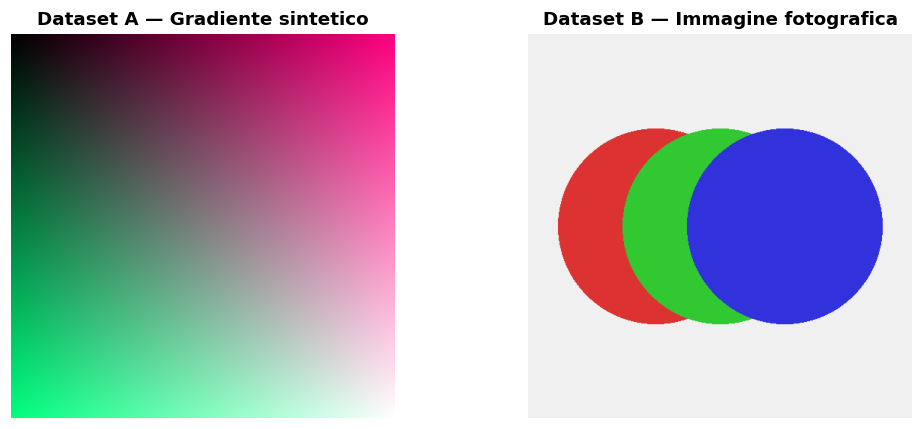

✅ Dataset pronto.


In [ ]:
# ✅ Generazione del dataset di test

# ── 1. Immagine sintetica: gradiente 2D RGB ──────────────────────────────────
def make_gradient(width=512, height=512):
    """Gradiente: R varia sull'asse X, G sull'asse Y, B è la media."""
    r = np.linspace(0, 255, width, dtype=np.uint8)[np.newaxis, :].repeat(height, axis=0)
    g = np.linspace(0, 255, height, dtype=np.uint8)[:, np.newaxis].repeat(width, axis=1)
    b = ((r.astype(np.float32) + g.astype(np.float32)) / 2).astype(np.uint8)
    return Image.fromarray(np.stack([r, g, b], axis=2), mode="RGB")

img_synth = make_gradient()
img_synth.save(OUTPUT_DIR / "synth.png")
print(f"Immagine sintetica : {img_synth.size}  mode={img_synth.mode}")

# ── 2. Immagine fotografica: download da Wikimedia (pubblico dominio) ─────────
PHOTO_URL  = "https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/PNG_transparency_demonstration_1.png/280px-PNG_transparency_demonstration_1.png"
PHOTO_PATH = OUTPUT_DIR / "photo.png"

if not PHOTO_PATH.exists():
    try:
        urllib.request.urlretrieve(PHOTO_URL, PHOTO_PATH)
        print("Foto scaricata da Wikimedia.")
    except Exception:
        # Fallback: cerchi colorati sovrapposti
        fb = Image.new("RGB", (512, 512), (240, 240, 240))
        draw = ImageDraw.Draw(fb)
        for cx, cy, r, col in [
            (170, 256, 130, (220, 50,  50)),
            (256, 256, 130, (50,  200, 50)),
            (342, 256, 130, (50,  50, 220)),
        ]:
            draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=col)
        fb.save(PHOTO_PATH)
        print("Download fallito — usata immagine di fallback.")

img_photo = Image.open(PHOTO_PATH).convert("RGB").resize((512, 512))
img_photo.save(OUTPUT_DIR / "photo.png")
print(f"Immagine fotografica: {img_photo.size}  mode={img_photo.mode}")

# ── Anteprima ─────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(img_synth); ax1.set_title("Dataset A — Gradiente sintetico", fontweight="bold"); ax1.axis("off")
ax2.imshow(img_photo);  ax2.set_title("Dataset B — Immagine fotografica",  fontweight="bold"); ax2.axis("off")
plt.tight_layout()
plt.show()
print("✅ Dataset pronto.")

---
## Sezione 1 — Caricare e ispezionare un'immagine

### Concetti chiave

Un'immagine digitale è una **matrice 2D (o 3D) di pixel**. Pillow la rappresenta come oggetto `Image`, con attributi che descrivono la struttura del dato:

| Attributo | Significato | Esempio |
|-----------|-------------|---------|
| `.size` | Tupla `(larghezza, altezza)` in pixel | `(512, 512)` |
| `.mode` | Spazio colore: `'L'` grigio, `'RGB'`, `'RGBA'`, `'P'` palette | `'RGB'` |
| `.format` | Formato del file sorgente (solo se aperto da file) | `'JPEG'` |

> ⚠️ **Attenzione:** `.size` restituisce `(larghezza, altezza)`, mentre NumPy usa la convenzione matriciale `(righe, colonne)` = `(altezza, larghezza)`. Questo invertimento è una fonte comune di bug.

  size   : (512, 512)   # (larghezza, altezza)
  mode   : RGB
  format : PNG

Dimensione non compressa (teorica): 768.0 KB
  = 512 × 512 × 3 byte


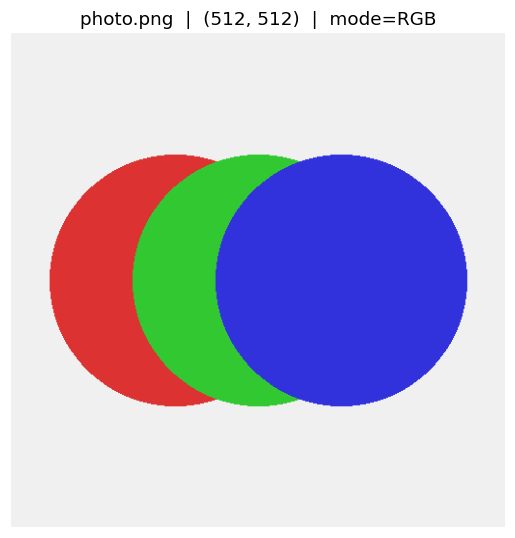

In [ ]:
# ✅ Apertura e ispezione degli attributi principali
img = Image.open(OUTPUT_DIR / "photo.png")

print("=" * 45)
print(f"  size   : {img.size}   # (larghezza, altezza)")
print(f"  mode   : {img.mode}")
print(f"  format : {img.format}")
print("=" * 45)

# Calcolo dimensione teorica non compressa
W, H    = img.size
canali  = len(img.getbands())
dim_kb  = W * H * canali / 1024
print(f"\nDimensione non compressa (teorica): {dim_kb:.1f} KB")
print(f"  = {W} × {H} × {canali} byte")

# Visualizzazione
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"photo.png  |  {img.size}  |  mode={img.mode}")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# ✅ Accesso ai pixel tramite array NumPy
arr = np.array(img)

print(f"Shape NumPy : {arr.shape}   # (altezza, larghezza, canali)")
print(f"dtype       : {arr.dtype}")
print(f"Range valori: [{arr.min()}, {arr.max()}]")
print()
print(f"Pixel alla riga=100, col=200 → {arr[100, 200]}")
print(f"  R={arr[100, 200, 0]}  G={arr[100, 200, 1]}  B={arr[100, 200, 2]}")

Shape NumPy : (512, 512, 3)   # (altezza, larghezza, canali)
dtype       : uint8
Range valori: [50, 240]

Pixel alla riga=100, col=200 → [240 240 240]
  R=240  G=240  B=240


In [ ]:
# 🔧 ESERCIZIO 1.1
# Confrontate la dimensione teorica non compressa dell'immagine sintetica
# con quella effettiva del file PNG su disco.
# Calcolate e stampate il rapporto di compressione.

img_s = Image.open(OUTPUT_DIR / "synth.png")
file_size_kb = os.path.getsize(OUTPUT_DIR / "synth.png") / 1024

# --- Completate qui ---
# W, H = img_s.size
# canali = ...
# dim_teorica_kb = ...
# rapporto = ...
# print(f"Dimensione teorica : {dim_teorica_kb:.1f} KB")
# print(f"Dimensione PNG     : {file_size_kb:.1f} KB")
# print(f"Rapporto (lossless): {rapporto:.2f}x")

---
## Sezione 2 — Operazioni geometriche di base

Pillow offre un'API intuitiva per le trasformazioni più comuni. Tutte restituiscono una **nuova immagine** senza modificare quella originale (Pillow è immutabile per design).

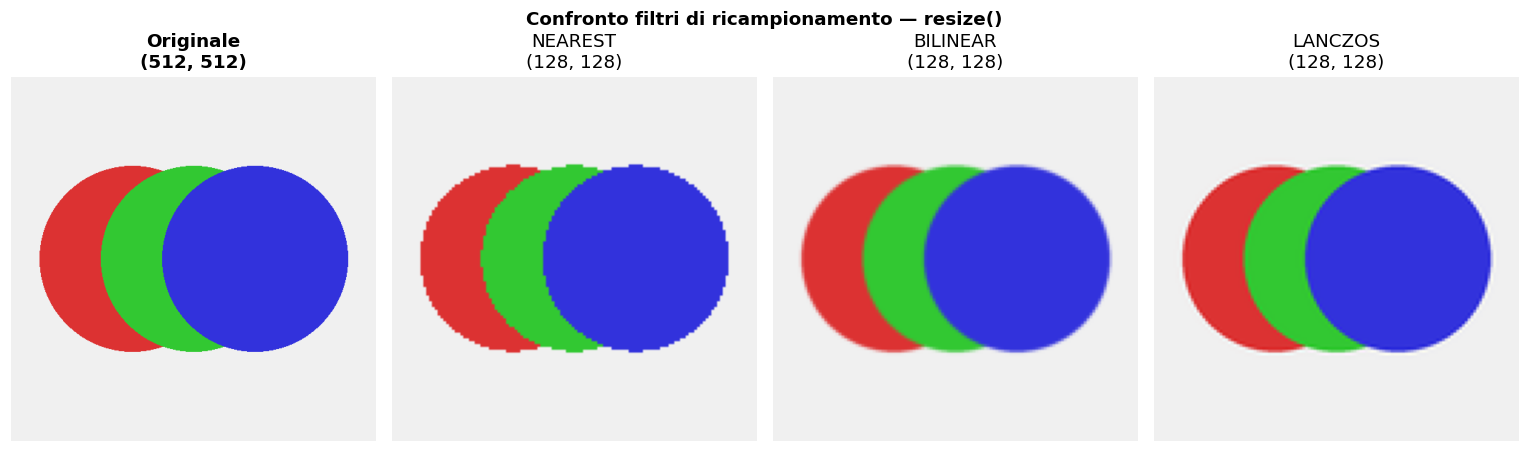

Osservate le differenze ai bordi e nelle zone con dettaglio fine.


In [ ]:
# ✅ 2.1 — Ridimensionamento (resize) e filtri di ricampionamento

img = Image.open(OUTPUT_DIR / "photo.png")
TARGET = (128, 128)

filtri = {
    "NEAREST":  Image.NEAREST,   # nessuna interpolazione, più veloce, copia nel nuovo pixel il valore del pixel più vicino nell'immagine originale
    "BILINEAR": Image.BILINEAR,  # interpolazione bilineare, copia nel nuovo pixel un valore che è la media dei 4 pixel più vicini nell'immagine originale
    "LANCZOS":  Image.LANCZOS,   # filtro Lanczos, massima qualità, come bilineare, ma usa 16 pixel
}

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(img)
axes[0].set_title(f"Originale\n{img.size}", fontweight="bold")
axes[0].axis("off")

for ax, (nome, filtro) in zip(axes[1:], filtri.items()):
    ridim = img.resize(TARGET, filtro)
    ax.imshow(ridim)
    ax.set_title(f"{nome}\n{TARGET}")
    ax.axis("off")

plt.suptitle("Confronto filtri di ricampionamento — resize()", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
print("Osservate le differenze ai bordi e nelle zone con dettaglio fine.")

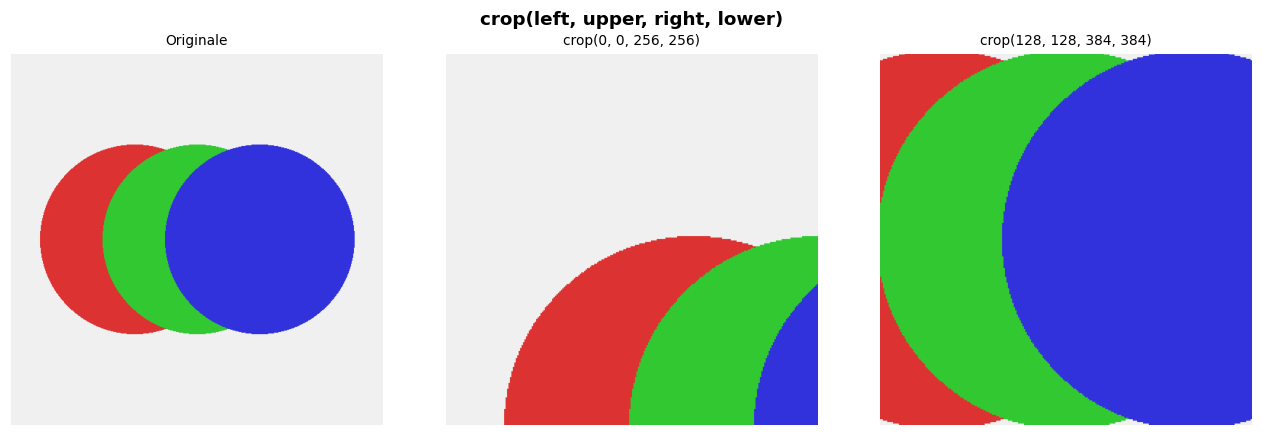

In [ ]:
# ✅ 2.2 — Ritaglio (crop)
# Le coordinate sono (left, upper, right, lower) in pixel — origine in alto a sinistra.

img = Image.open(OUTPUT_DIR / "photo.png")
W, H = img.size

box_topleft = (0, 0, W // 2, H // 2)                                       # quadrante alto-sinistra
box_center  = (int(W * 0.25), int(H * 0.25), int(W * 0.75), int(H * 0.75)) # centro 50%

crop_tl = img.crop(box_topleft)
crop_ct = img.crop(box_center)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (titolo, im) in zip(axes, [
    ("Originale", img),
    (f"crop{box_topleft}", crop_tl),
    (f"crop{box_center}",  crop_ct),
]):
    ax.imshow(im); ax.set_title(titolo, fontsize=9); ax.axis("off")

plt.suptitle("crop(left, upper, right, lower)", fontweight="bold")
plt.tight_layout()
plt.show()

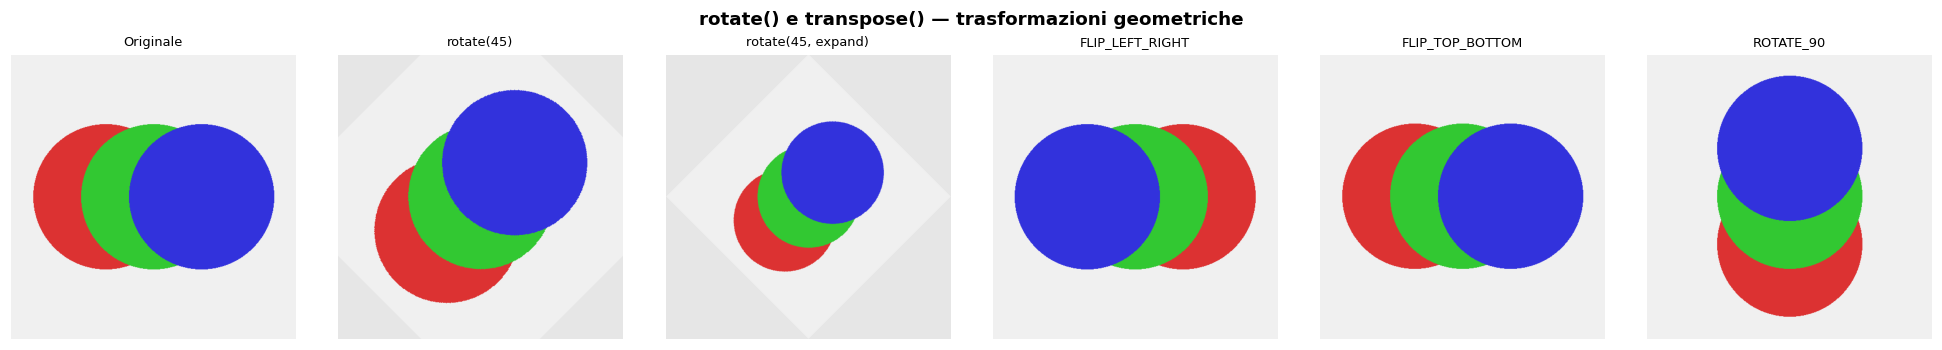

expand=True ridimensiona il canvas per contenere l'immagine ruotata intera.


In [ ]:
# ✅ 2.3 — Rotazione e flip

img = Image.open(OUTPUT_DIR / "photo.png")

varianti = [
    ("Originale",          img),
    ("rotate(45)",         img.rotate(45, expand=False, fillcolor=(230, 230, 230))),
    ("rotate(45, expand)", img.rotate(45, expand=True,  fillcolor=(230, 230, 230))),
    ("FLIP_LEFT_RIGHT",    img.transpose(Image.FLIP_LEFT_RIGHT)),
    ("FLIP_TOP_BOTTOM",    img.transpose(Image.FLIP_TOP_BOTTOM)),
    ("ROTATE_90",          img.transpose(Image.ROTATE_90)),
]

fig, axes = plt.subplots(1, 6, figsize=(18, 3.2))
for ax, (titolo, im) in zip(axes, varianti):
    ax.imshow(im); ax.set_title(titolo, fontsize=8.5); ax.axis("off")

plt.suptitle("rotate() e transpose() — trasformazioni geometriche", fontweight="bold")
plt.tight_layout()
plt.show()
print("expand=True ridimensiona il canvas per contenere l'immagine ruotata intera.")

In [ ]:
# 🔧 ESERCIZIO 2.1
# Partendo dall'immagine sintetica:
#   a) Create una thumbnail 200×200 con filtro LANCZOS
#   b) Ruotatela di 30° con expand=True e sfondo nero
#   c) Mostrate i due risultati affiancati
#
# Suggerimento: Image.new("RGB", size, color) crea un'immagine di sfondo.

img_s = Image.open(OUTPUT_DIR / "synth.png")

# --- Completate qui ---
# thumb   = ...
# ruotata = ...
#
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
# ax1.imshow(thumb);   ax1.set_title("Thumbnail 200×200"); ax1.axis("off")
# ax2.imshow(ruotata); ax2.set_title("Ruotata 30°");       ax2.axis("off")
# plt.tight_layout(); plt.show()

---
## Sezione 3 — Conversione tra modalità

La **modalità** (`mode`) definisce come Pillow interpreta i valori di ciascun pixel. La conversione si fa con `.convert(mode)`.

| Mode | Canali | Byte/pixel | Uso tipico |
|------|--------|-----------|------------|
| `'L'` | 1 (grigio) | 1 | Imaging medico, machine learning |
| `'RGB'` | 3 | 3 | Fotografie, display |
| `'RGBA'` | 4 (R,G,B,Alfa) | 4 | Web, compositing |
| `'P'` | 1 (indice palette) | 1 + LUT | GIF, grafica piatta |
| `'CMYK'` | 4 | 4 | Stampa professionale |

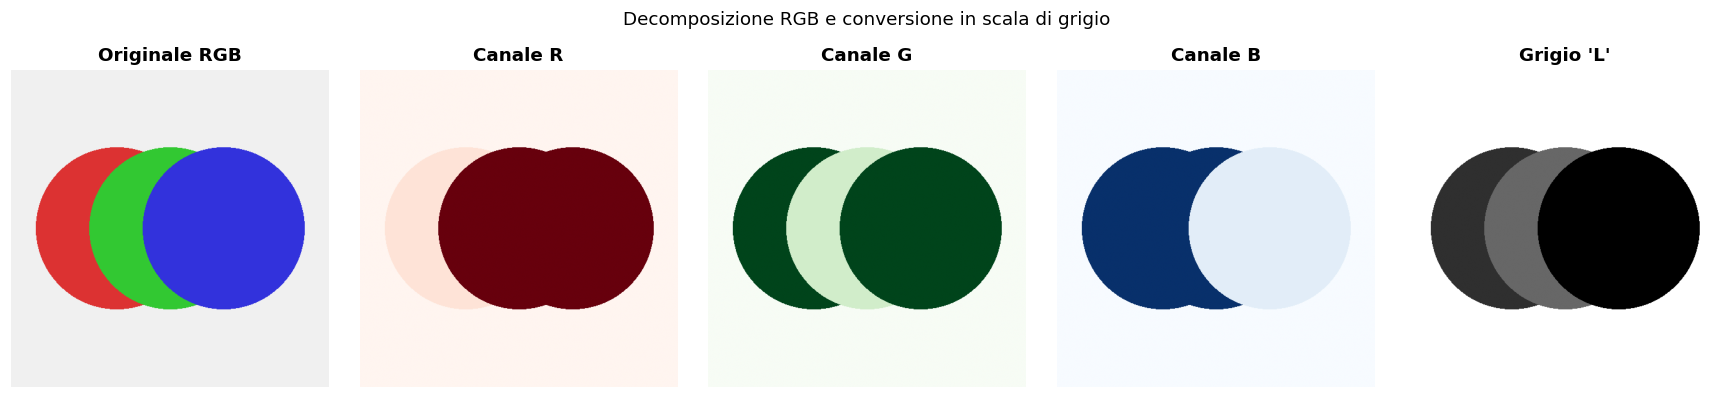

RGB  : size=(512, 512), mode=RGB, shape=(512, 512, 3)
Gray : size=(512, 512), mode=L, shape=(512, 512)


In [ ]:
# ✅ 3.1 — RGB → Scala di grigio ('L')
# La formula standard (ITU-R BT.601) è: Y = 0.299·R + 0.587·G + 0.114·B
# I pesi diversi riflettono la sensibilità dell'occhio umano ai tre canali.

img      = Image.open(OUTPUT_DIR / "photo.png")
img_gray = img.convert("L")

arr      = np.array(img)
arr_gray = np.array(img_gray)

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
for ax, (titolo, data, cm) in zip(axes, [
    ("Originale RGB",  arr,           None),
    ("Canale R",       arr[:,:,0],    "Reds_r"),
    ("Canale G",       arr[:,:,1],    "Greens_r"),
    ("Canale B",       arr[:,:,2],    "Blues_r"),
    ("Grigio 'L'",     arr_gray,      "gray"),
]):
    ax.imshow(data, cmap=cm)
    ax.set_title(titolo, fontweight="bold")
    ax.axis("off")

plt.suptitle("Decomposizione RGB e conversione in scala di grigio", y=1.02)
plt.tight_layout()
plt.show()

print(f"RGB  : size={img.size}, mode={img.mode}, shape={arr.shape}")
print(f"Gray : size={img_gray.size}, mode={img_gray.mode}, shape={arr_gray.shape}")

Shape RGBA: (512, 512, 4)   (H × W × 4)
Canale alfa: min=255, max=255  (255 = opaco)


/tmp/ipykernel_7033/2370190966.py:15: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img_fade = Image.fromarray(arr_fade, mode="RGBA")


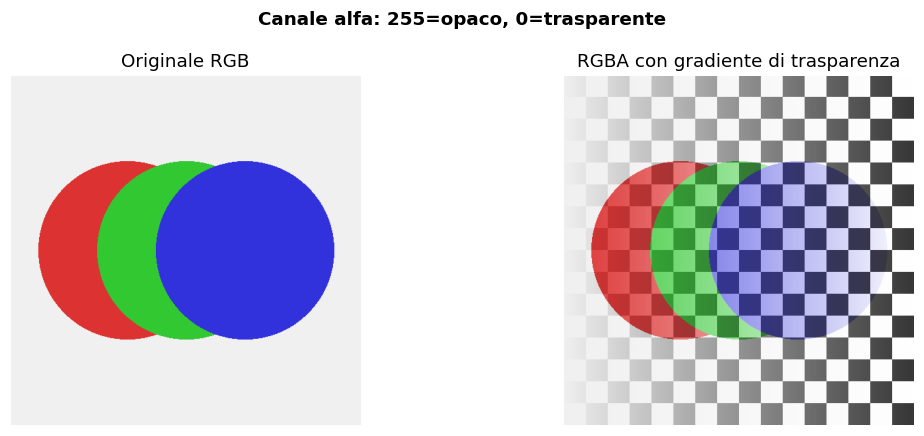

In [ ]:
# ✅ 3.2 — RGB → RGBA: aggiunta del canale alfa (trasparenza)

img      = Image.open(OUTPUT_DIR / "photo.png")
img_rgba = img.convert("RGBA")

arr_rgba = np.array(img_rgba)
print(f"Shape RGBA: {arr_rgba.shape}   (H × W × 4)")
print(f"Canale alfa: min={arr_rgba[:,:,3].min()}, max={arr_rgba[:,:,3].max()}  (255 = opaco)")

# Creiamo un gradiente di trasparenza orizzontale
arr_fade = arr_rgba.copy()
W = arr_fade.shape[1]
arr_fade[:, :, 3] = np.linspace(255, 0, W, dtype=np.uint8)[np.newaxis, :]

img_fade = Image.fromarray(arr_fade, mode="RGBA")

# Compositing su sfondo a scacchi (pattern tipico per visualizzare trasparenza)
H_px, W_px = arr_fade.shape[:2]
tile = 32
xs, ys = np.arange(W_px) // tile, np.arange(H_px) // tile
cb = (((xs[np.newaxis, :] + ys[:, np.newaxis]) % 2) * 200 + 55).astype(np.uint8)
cb3 = np.stack([cb, cb, cb], axis=2)
alpha = arr_fade[:, :, 3:4] / 255.0
comp = (arr_fade[:, :, :3] * alpha + cb3 * (1 - alpha)).astype(np.uint8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.imshow(img);  ax1.set_title("Originale RGB");                  ax1.axis("off")
ax2.imshow(comp); ax2.set_title("RGBA con gradiente di trasparenza"); ax2.axis("off")
plt.suptitle("Canale alfa: 255=opaco, 0=trasparente", fontweight="bold")
plt.tight_layout()
plt.show()

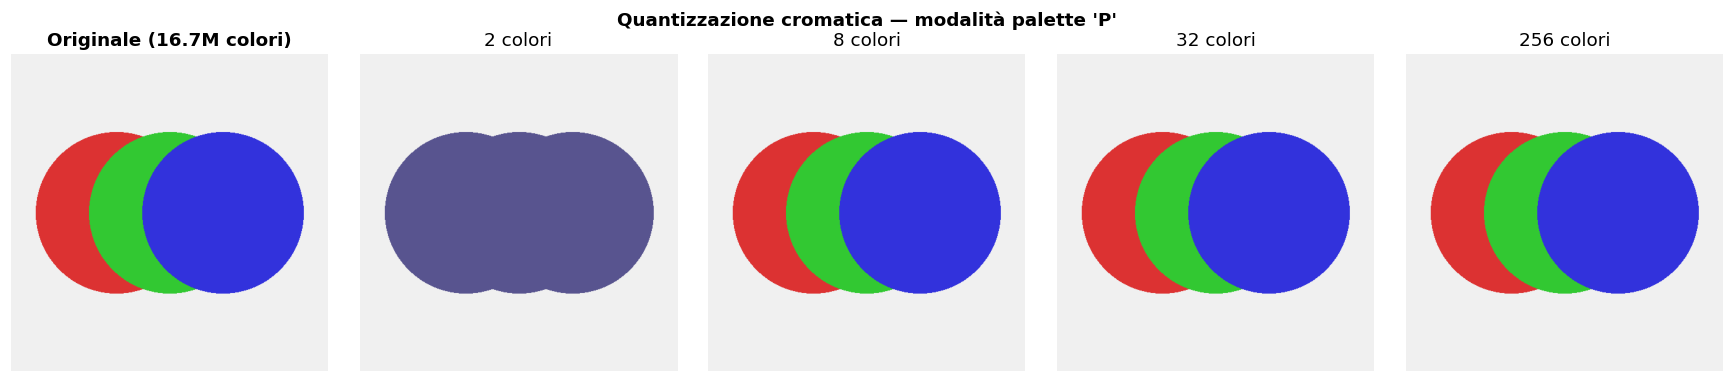

Con pochi colori emergono bordi netti tra zone (posterizzazione).


In [ ]:
# ✅ 3.3 — RGB → Palette ('P'): quantizzazione cromatica
# Riduce i colori a una palette di N colori usando l'algoritmo Median Cut.
# Questo è il meccanismo alla base del formato GIF.

img = Image.open(OUTPUT_DIR / "photo.png")

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
axes[0].imshow(img); axes[0].set_title("Originale (16.7M colori)", fontweight="bold"); axes[0].axis("off")

for ax, n_colori in zip(axes[1:], [2, 8, 32, 256]):
    img_q = img.quantize(colors=n_colori, method=Image.Quantize.MEDIANCUT).convert("RGB")
    ax.imshow(img_q)
    ax.set_title(f"{n_colori} colori")
    ax.axis("off")

plt.suptitle("Quantizzazione cromatica — modalità palette 'P'", fontweight="bold")
plt.tight_layout()
plt.show()
print("Con pochi colori emergono bordi netti tra zone (posterizzazione).")

In [ ]:
# 🔧 ESERCIZIO 3.1
# Convertite l'immagine sintetica in CMYK e visualizzate i 4 canali separatamente.
# Usate colormap specifiche per ciascun canale (Reds, Greens, Blues, gray).
# Domanda: il canale K (nero) è vuoto per questa immagine? Perché?

img_s = Image.open(OUTPUT_DIR / "synth.png")

# --- Completate qui ---
# img_cmyk = img_s.convert("CMYK")
# arr_cmyk = np.array(img_cmyk)
# nomi   = ["C (Cyan)", "M (Magenta)", "Y (Yellow)", "K (Key/Nero)"]
# cmaps  = ["Blues", "RdPu", "YlOrBr", "gray"]
# fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
# for ax, (nome, cmap) in zip(axes, zip(nomi, cmaps)):
#     ...

---
## Sezione 4 — Salvataggio in formati diversi e misurazione della dimensione

### Il quality factor JPEG

Il parametro `quality` (1–95, o 100 per massimo) controlla l'aggressività della quantizzazione delle tabelle DCT:

- **quality bassa** → molti coefficienti azzerati → file piccolo, molti artefatti
- **quality alta** → poca perdita → file grande, artefatti quasi invisibili

Il valore di default di Pillow è **75** (buon compromesso per fotografie).

In [ ]:
# ✅ 4.1 — Salvataggio in BMP, PNG (vari livelli), JPEG (vari quality)

img = Image.open(OUTPUT_DIR / "photo.png")

# BMP: nessuna compressione
img.save(OUTPUT_DIR / "out.bmp")

# PNG: compress_level cambia velocità ma NON la qualità (sempre lossless)
for lvl in [0, 6, 9]:
    img.save(OUTPUT_DIR / f"out_png_c{lvl}.png", compress_level=lvl)

# JPEG: quality regola il trade-off qualità/dimensione
QUALITY_VALUES = [5, 10, 20, 35, 50, 65, 75, 85, 95, 100]
for q in QUALITY_VALUES:
    img.save(OUTPUT_DIR / f"out_q{q:03d}.jpg", quality=q, subsampling=0)

# Riepilogo dimensioni
print(f"{'File':<26} {'Dimensione':>12}")
print("-" * 40)
for nome in ["out.bmp",
              "out_png_c0.png", "out_png_c6.png", "out_png_c9.png"]:
    sz = os.path.getsize(OUTPUT_DIR / nome) / 1024
    print(f"{nome:<26} {sz:>10.1f} KB")
print()
for q in QUALITY_VALUES:
    nome = f"out_q{q:03d}.jpg"
    sz = os.path.getsize(OUTPUT_DIR / nome) / 1024
    print(f"{nome:<26} {sz:>10.1f} KB")
print("\n✅ Tutti i file salvati.")

File                         Dimensione
----------------------------------------
out.bmp                         768.1 KB
out_png_c0.png                  768.8 KB
out_png_c6.png                    3.6 KB
out_png_c9.png                    2.8 KB

out_q005.jpg                      8.5 KB
out_q010.jpg                      9.3 KB
out_q020.jpg                     10.5 KB
out_q035.jpg                     12.1 KB
out_q050.jpg                     13.4 KB
out_q065.jpg                     15.0 KB
out_q075.jpg                     16.9 KB
out_q085.jpg                     20.3 KB
out_q095.jpg                     29.9 KB
out_q100.jpg                     50.0 KB

✅ Tutti i file salvati.


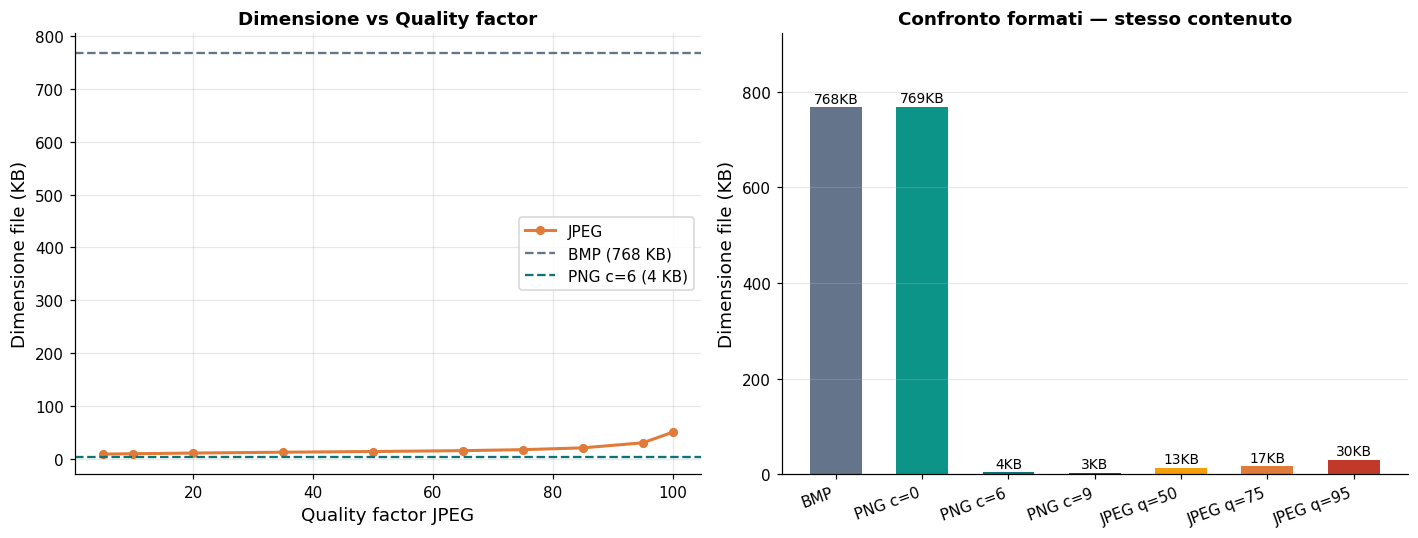

Rapporto BMP / JPEG(q=75): 45.4x
Rapporto PNG / JPEG(q=75): 0.2x


In [ ]:
# ✅ 4.2 — Curva dimensione file vs quality factor

sizes_jpg = {q: os.path.getsize(OUTPUT_DIR / f"out_q{q:03d}.jpg") / 1024
             for q in QUALITY_VALUES}

sz_bmp    = os.path.getsize(OUTPUT_DIR / "out.bmp")         / 1024
sz_png_c6 = os.path.getsize(OUTPUT_DIR / "out_png_c6.png")  / 1024

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Grafico 1: curva JPEG + linee di riferimento ──────────────────────────────
ax = axes[0]
ax.plot(list(sizes_jpg.keys()), list(sizes_jpg.values()),
        "-o", color="#E07B39", linewidth=2, markersize=5, label="JPEG")
ax.axhline(sz_bmp,    color="#64748B", ls="--", lw=1.5, label=f"BMP ({sz_bmp:.0f} KB)")
ax.axhline(sz_png_c6, color="#0D7377", ls="--", lw=1.5, label=f"PNG c=6 ({sz_png_c6:.0f} KB)")
ax.set_xlabel("Quality factor JPEG",  fontsize=12)
ax.set_ylabel("Dimensione file (KB)", fontsize=12)
ax.set_title("Dimensione vs Quality factor", fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3)

# ── Grafico 2: confronto a barre ──────────────────────────────────────────────
ax2 = axes[1]
etichette  = ["BMP", "PNG c=0", "PNG c=6", "PNG c=9",
               "JPEG q=50", "JPEG q=75", "JPEG q=95"]
dimensioni = [
    sz_bmp,
    os.path.getsize(OUTPUT_DIR / "out_png_c0.png") / 1024,
    sz_png_c6,
    os.path.getsize(OUTPUT_DIR / "out_png_c9.png") / 1024,
    sizes_jpg[50], sizes_jpg[75], sizes_jpg[95],
]
colori = ["#64748B", "#0D9488", "#0D7377", "#065A82",
          "#F59E0B", "#E07B39", "#C0392B"]
bars = ax2.bar(etichette, dimensioni, color=colori, width=0.6)
for bar, dim in zip(bars, dimensioni):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
             f"{dim:.0f}KB", ha="center", va="bottom", fontsize=9)
ax2.set_ylabel("Dimensione file (KB)", fontsize=12)
ax2.set_title("Confronto formati — stesso contenuto", fontweight="bold")
ax2.set_ylim(0, max(dimensioni) * 1.2)
ax2.grid(True, alpha=0.3, axis="y")
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

print(f"Rapporto BMP / JPEG(q=75): {sz_bmp / sizes_jpg[75]:.1f}x")
print(f"Rapporto PNG / JPEG(q=75): {sz_png_c6 / sizes_jpg[75]:.1f}x")

In [ ]:
# 🔧 ESERCIZIO 4.1
# Ripetete la stessa analisi usando l'immagine SINTETICA.
# Come cambia la curva dimensione/quality rispetto alla fotografica?
# Perché il PNG comprime il gradiente diversamente da una fotografia?
# (Suggerimento: pensate all'entropia del contenuto.)

img_s = Image.open(OUTPUT_DIR / "synth.png")

# --- Completate qui ---

---
## Sezione 5 — Visualizzazione comparativa e artefatti JPEG

### Artefatti della compressione JPEG

La DCT opera su **blocchi 8×8 pixel**. La quantizzazione aggressiva di questi blocchi introduce artefatti caratteristici:

| Artefatto | Causa | Dove si vede |
|-----------|-------|--------------|
| **Blocchettizzazione** | Confini visibili tra blocchi DCT 8×8 | quality < 20, zone uniformi |
| **Ringing** | Troncamento frequenze alte → oscillazioni di Gibbs | bordi netti, testi |
| **Perdita di dettaglio** | Coefficienti ad alta frequenza → 0 | texture fini, pelo, foglie |
| **Color bleeding** | Crominanza sub-campionata (4:2:0) | bordi tra colori saturi |

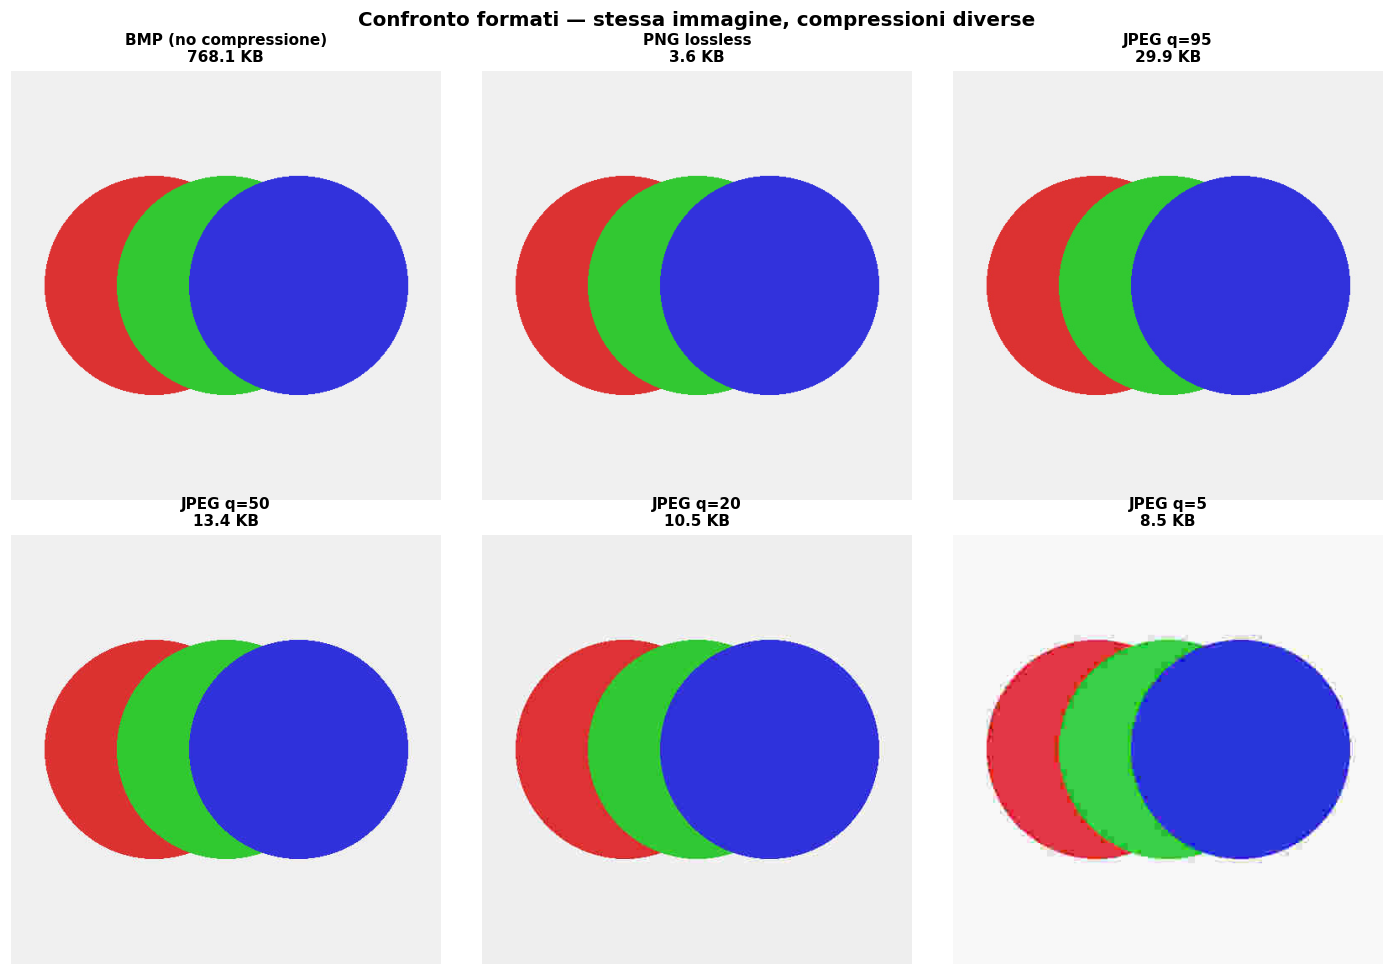

In [ ]:
# ✅ 5.1 — Confronto visivo: BMP, PNG e JPEG a quality diverse

formati_confronto = [
    ("BMP (no compressione)",  "out.bmp"),
    ("PNG lossless",           "out_png_c6.png"),
    ("JPEG q=95",              "out_q095.jpg"),
    ("JPEG q=50",              "out_q050.jpg"),
    ("JPEG q=20",              "out_q020.jpg"),
    ("JPEG q=5",               "out_q005.jpg"),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, (titolo, nome_file) in zip(axes.flat, formati_confronto):
    im = Image.open(OUTPUT_DIR / nome_file)
    sz = os.path.getsize(OUTPUT_DIR / nome_file) / 1024
    ax.imshow(im)
    ax.set_title(f"{titolo}\n{sz:.1f} KB", fontweight="bold", fontsize=10)
    ax.axis("off")

plt.suptitle("Confronto formati — stessa immagine, compressioni diverse",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

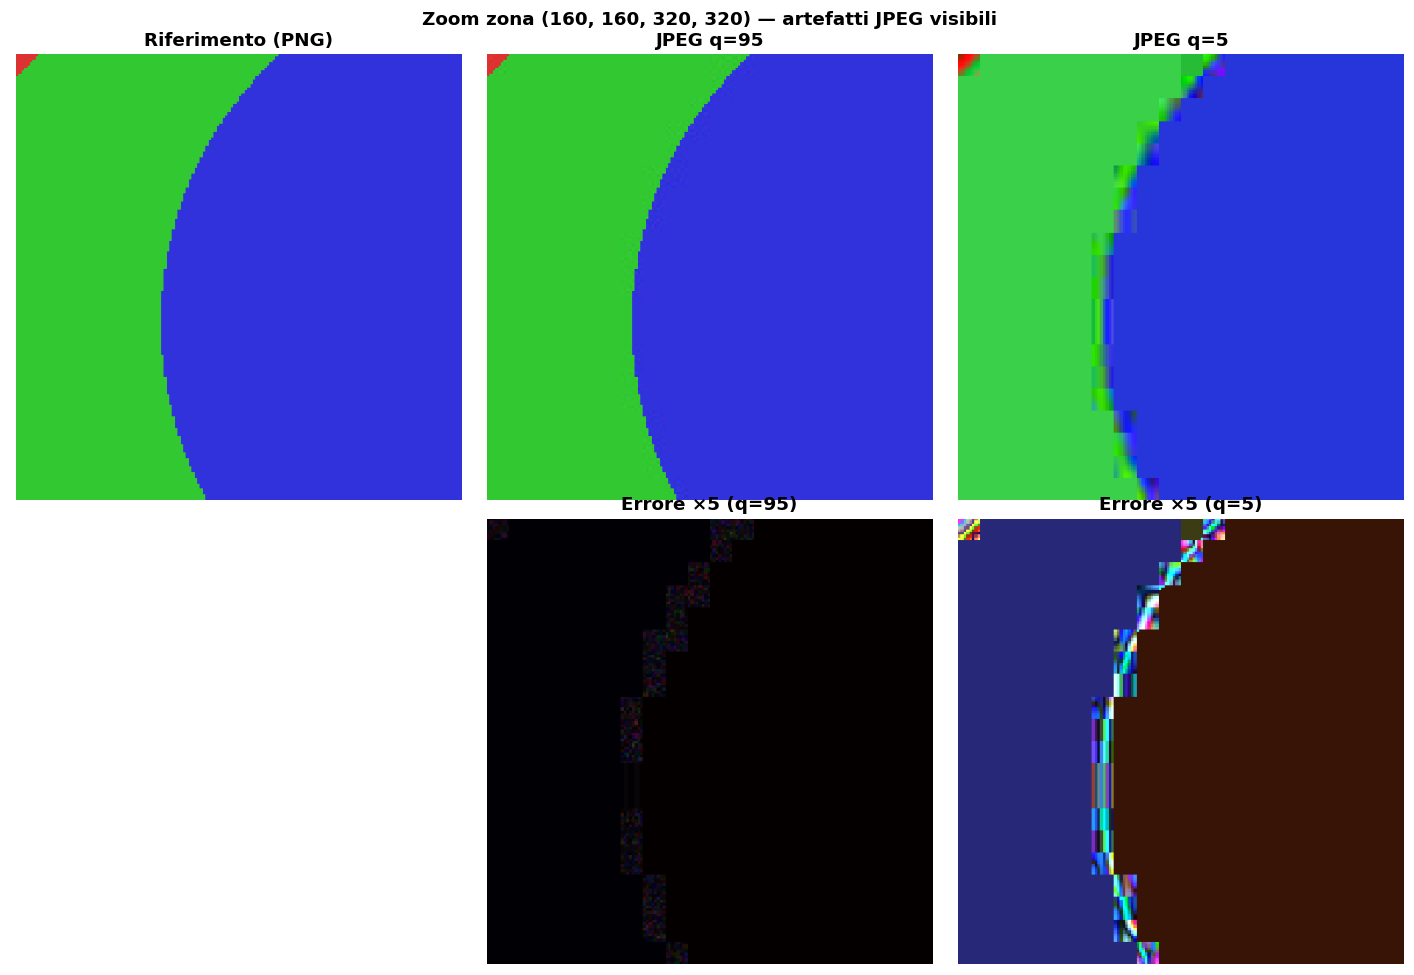

JPEG q=95  →  MSE=    0.96  |  PSNR=48.30 dB
JPEG q=5   →  MSE=  139.47  |  PSNR=26.69 dB


In [ ]:
# ✅ 5.2 — Zoom sugli artefatti: analisi locale
# Ritagliamo la stessa zona da più versioni e amplifichiamo l'errore.

ZOOM_BOX = (160, 160, 320, 320)   # (left, upper, right, lower)
ZOOM_SIZE = (384, 384)             # dimensione di visualizzazione

ref    = Image.open(OUTPUT_DIR / "out_png_c6.png")
j_95   = Image.open(OUTPUT_DIR / "out_q095.jpg")
j_5    = Image.open(OUTPUT_DIR / "out_q005.jpg")

z_ref  = ref.crop(ZOOM_BOX).resize(ZOOM_SIZE, Image.NEAREST)
z_95   = j_95.crop(ZOOM_BOX).resize(ZOOM_SIZE, Image.NEAREST)
z_5    = j_5.crop(ZOOM_BOX).resize(ZOOM_SIZE,  Image.NEAREST)

def errore_amplificato(a, b, fattore=5):
    diff = np.abs(np.array(a).astype(int) - np.array(b).astype(int)) * fattore
    return Image.fromarray(np.clip(diff, 0, 255).astype(np.uint8))

err_95 = errore_amplificato(z_ref, z_95)
err_5  = errore_amplificato(z_ref, z_5)

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, (titolo, im) in zip(axes[0], [
    ("Riferimento (PNG)", z_ref),
    ("JPEG q=95",         z_95),
    ("JPEG q=5",          z_5),
]):
    ax.imshow(im); ax.set_title(titolo, fontweight="bold"); ax.axis("off")

axes[1, 0].axis("off")
for ax, (titolo, im) in zip(axes[1, 1:], [
    ("Errore ×5 (q=95)", err_95),
    ("Errore ×5 (q=5)",  err_5),
]):
    ax.imshow(im); ax.set_title(titolo, fontweight="bold"); ax.axis("off")

plt.suptitle(f"Zoom zona {ZOOM_BOX} — artefatti JPEG visibili", fontweight="bold")
plt.tight_layout()
plt.show()

# Calcolo PSNR
for label, compressed in [("q=95", j_95), ("q=5", j_5)]:
    err  = np.array(ref).astype(float) - np.array(compressed).astype(float)
    mse  = (err ** 2).mean()
    psnr = 10 * math.log10(255**2 / mse) if mse > 0 else float("inf")
    print(f"JPEG {label:<5} →  MSE={mse:8.2f}  |  PSNR={psnr:.2f} dB")

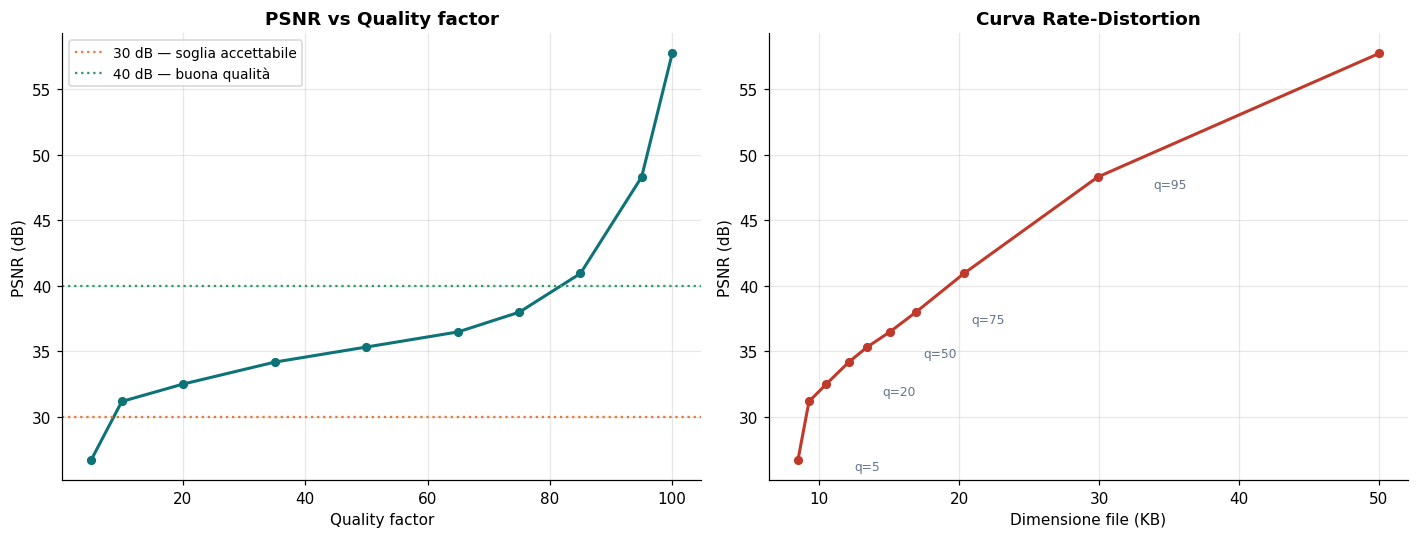

Osservate: sopra q=75 il PSNR cresce poco ma i KB aumentano molto.


In [ ]:
# ✅ 5.3 — Curva rate-distortion: PSNR vs quality factor

def psnr(ref_img, comp_img):
    """Peak Signal-to-Noise Ratio (dB). Più alto = meno distorsione."""
    a = np.array(ref_img).astype(float)
    b = np.array(comp_img).astype(float)
    mse = ((a - b) ** 2).mean()
    return 10 * math.log10(255**2 / mse) if mse > 0 else float("inf")

ref = Image.open(OUTPUT_DIR / "out_png_c6.png")

psnr_vals = {q: psnr(ref, Image.open(OUTPUT_DIR / f"out_q{q:03d}.jpg"))
             for q in QUALITY_VALUES}
size_vals = {q: os.path.getsize(OUTPUT_DIR / f"out_q{q:03d}.jpg") / 1024
             for q in QUALITY_VALUES}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# PSNR vs quality
ax1.plot(list(psnr_vals.keys()), list(psnr_vals.values()),
         "-o", color="#0D7377", linewidth=2, markersize=5)
ax1.axhline(30, color="#E07B39", ls=":", label="30 dB — soglia accettabile")
ax1.axhline(40, color="#2D9E6B", ls=":", label="40 dB — buona qualità")
ax1.set_xlabel("Quality factor"); ax1.set_ylabel("PSNR (dB)")
ax1.set_title("PSNR vs Quality factor", fontweight="bold")
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

# Curva rate-distortion
ax2.plot(list(size_vals.values()), list(psnr_vals.values()),
         "-o", color="#C0392B", linewidth=2, markersize=5)
for q in [5, 20, 50, 75, 95]:
    ax2.annotate(f"q={q}",
                 xy=(size_vals[q], psnr_vals[q]),
                 xytext=(size_vals[q] + 4, psnr_vals[q] - 0.8),
                 fontsize=8, color="#64748B")
ax2.set_xlabel("Dimensione file (KB)"); ax2.set_ylabel("PSNR (dB)")
ax2.set_title("Curva Rate-Distortion", fontweight="bold")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Osservate: sopra q=75 il PSNR cresce poco ma i KB aumentano molto.")

---
## Sezione 6 — Esercizi ed esperimenti

In [ ]:
# 🔧 ESERCIZIO 6.1 — PSNR sull'immagine sintetica
#
# Ripetete l'analisi PSNR della Sezione 5.3 usando img_synth.
# Confrontate le due curve rate-distortion sullo stesso grafico.
# Quale immagine tollera meglio la compressione JPEG? Perché?

# --- Completate qui ---

In [ ]:
# 🔧 ESERCIZIO 6.2 — Subsampling cromatico
#
# Salvate la stessa immagine a q=75 con:
#   - subsampling=0  (4:4:4, nessuna riduzione della crominanza)
#   - subsampling=2  (4:2:0, riduzione crominanza al 50%, default JPEG)
# Confrontate dimensione su disco e PSNR.
# In quale zona dell'immagine vedete più differenza?

img = Image.open(OUTPUT_DIR / "photo.png")

# --- Completate qui ---
# img.save(OUTPUT_DIR / "out_444.jpg", quality=75, subsampling=0)
# img.save(OUTPUT_DIR / "out_420.jpg", quality=75, subsampling=2)
# ...

In [ ]:
# 🔧 ESERCIZIO 6.3 — JPEG progressivo
#
# Salvate la stessa immagine come JPEG standard e JPEG progressivo.
# Il JPEG progressivo trasmette prima le basse frequenze (immagine sfocata)
# e poi le alte (dettagli): il browser mostra subito una bassa risoluzione.
#
# img.save(OUTPUT_DIR / "out_standard.jpg",    quality=75, progressive=False)
# img.save(OUTPUT_DIR / "out_progressive.jpg", quality=75, progressive=True)
#
# Confrontate le dimensioni. Quale è più piccolo? La differenza dipende
# dal contenuto (fotografia vs grafica)?

# --- Completate qui ---

In [ ]:
# 🔧 ESERCIZIO 6.4 — Degradazione cumulativa (JPEG generazionale)
#
# Cosa succede se si apre e risalva un JPEG più volte?
# Ogni salvataggio introduce nuova perdita (la quantizzazione non è idempotente).
# Simulate 10 generazioni a quality=50 e calcolate il PSNR a ogni passo.

GENERAZIONI = 10
QUALITY_GEN = 50

# --- Completate qui ---
# from io import BytesIO
# img_iter = Image.open(OUTPUT_DIR / "out_q075.jpg")
# ref_arr  = np.array(img_iter).astype(float)
# psnr_gen = []
#
# for i in range(GENERAZIONI):
#     buf = BytesIO()
#     img_iter.save(buf, format="JPEG", quality=QUALITY_GEN)
#     buf.seek(0)
#     img_iter = Image.open(buf).copy()
#     mse = ((ref_arr - np.array(img_iter).astype(float)) ** 2).mean()
#     psnr_gen.append(10 * math.log10(255**2 / mse))
#
# plt.plot(range(1, GENERAZIONI+1), psnr_gen, "-o", color="#C0392B")
# plt.xlabel("Generazione"); plt.ylabel("PSNR (dB)")
# plt.title(f"Degradazione JPEG cumulativa (q={QUALITY_GEN})")
# plt.grid(True, alpha=0.3); plt.show()

In [ ]:
# 🔧 ESERCIZIO 6.5 (AVANZATO) — thumbnail() vs resize()
#
# Pillow ha .thumbnail(max_size) che ridimensiona PRESERVANDO le proporzioni
# e modifica l'immagine IN-PLACE (a differenza di .resize()).
# Create un'immagine rettangolare (es. 800×400), poi:
#   a) Applicatele .thumbnail((200, 200))
#   b) Applicatele .resize((200, 200))
# Confrontate i risultati. Quale distorce il soggetto?

# --- Completate qui ---
# img_rect = img_photo.resize((800, 400))
#
# img_thumb = img_rect.copy()
# img_thumb.thumbnail((200, 200), Image.LANCZOS)
#
# img_resized = img_rect.resize((200, 200), Image.LANCZOS)
#
# print(f"thumbnail: {img_thumb.size}")
# print(f"resize:    {img_resized.size}")
# ...

---
## Riepilogo

<div style="background:#F0FDF9; border-left:5px solid #0D7377; padding:20px 24px; border-radius:6px">

### Cosa abbiamo imparato

1. **`Image.open()` e attributi** — accesso immediato a `size`, `mode`, `format`; conversione in NumPy con `np.array()`. Ricordate che `size` è `(W, H)` mentre NumPy usa `(H, W, C)`.

2. **Trasformazioni geometriche** — `resize()`, `crop()`, `rotate()`, `transpose()` restituiscono sempre una nuova immagine. LANCZOS dà la massima qualità nel downsampling.

3. **Conversione di modalità** — `convert('L')` usa i pesi ITU-R (G conta di più); `convert('RGBA')` aggiunge alfa=255; `quantize()` riduce i colori con Median Cut.

4. **Formato e dimensione** — BMP ≫ PNG ≥ JPEG in byte su disco. PNG è sempre lossless (il `compress_level` cambia solo la velocità). JPEG è lossy con trade-off regolabile.

5. **Artefatti JPEG** — blocchettizzazione, ringing e color bleeding derivano tutti dalla quantizzazione aggressiva dei coefficienti DCT. Il PSNR quantifica la perdita; la curva rate-distortion mostra che sopra q=75 i guadagni di qualità costano molto spazio.

</div>

---

### Riferimenti

- Ze-Nian Li, Mark S. Drew, Jiangchuan Liu — *Fundamentals of Multimedia*, Pearson, cap. 3
- [Pillow documentation](https://pillow.readthedocs.io/en/stable/) — API completa
- [matplotlib documentation](https://matplotlib.org/stable/) — visualizzazione
- Lezioni teoriche del corso: **Lezione 2** (Rappresentazione digitale delle immagini), **Lezione 3** (Formati popolari per immagini)